# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [2]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [3]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [4]:
class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()

        # 6 -> 16
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        # 16 -> 8
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        # 8 -> 4 (linear output)
        self.fc3 = nn.Linear(h2, out_dim)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)   # no activation (regression output)

        return x

In [5]:
# Create model
model = DNN_Reg4().to(device)

# Loss function (MSE)
loss_fn = nn.MSELoss()

# Optimizer (Adam + L2 regularization)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

In [7]:
def train_part1(model, loader, epochs=EPOCHS):
    model.train()

    for ep in range(1, epochs + 1):
        total = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero gradients
            optimizer.zero_grad()

            # forward
            preds = model(xb)

            # loss
            loss = loss_fn(preds, yb)

            # backward
            loss.backward()

            # step
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch {ep}/{epochs}  |  Loss: {avg_loss:.6f}")

In [8]:
train_part1(model, train_loader_1)

Epoch 1/1000  |  Loss: 0.766126
Epoch 500/1000  |  Loss: 0.102731
Epoch 1000/1000  |  Loss: 0.102912


In [9]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8992    0.7690    0.8290      2377
           C     0.9924    0.9174    0.9534      2263
           B     0.9452    0.9653    0.9552      3057
           A     0.9781    0.9793    0.9787      3144

   micro avg     0.9557    0.9163    0.9356     10841
   macro avg     0.9537    0.9078    0.9291     10841
weighted avg     0.9545    0.9163    0.9340     10841
 samples avg     0.6610    0.6477    0.6486     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2920  205]
 [ 549 1828]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3223   16]
 [ 187 2076]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2274  171]
 [ 106 2951]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2289   69]
 [  65 3079]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8995    0.7556    0.8213      1019
           C     0.9845    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

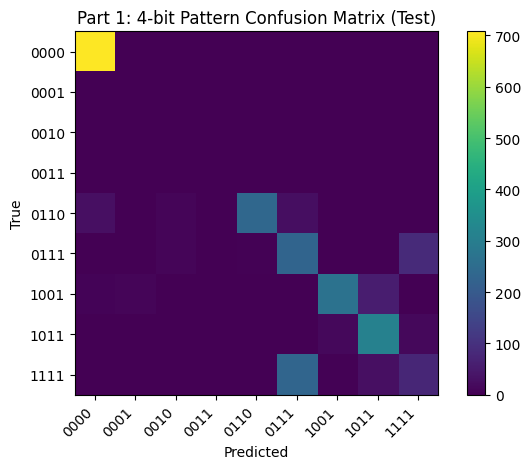

[[708   1   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 28   0  11   0 237  25   0   0   0]
 [  0   0  11   0   4 229   0   0  85]
 [  7   9   0   0   0   0 266  57   0]
 [  0   0   0   1   0   0  14 311  14]
 [  0   0   0   0   0 232   4  29  75]]


In [10]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [11]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [12]:
class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()

        # 6 -> 16
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        # 16 -> 8
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        # 8 -> 4 (logits)
        self.fc3 = nn.Linear(h2, out_dim)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop2(x)

        logits = self.fc3(x)   # no sigmoid here

        return logits

In [14]:
# Create model
model_2 = DNN_MultiLabel4().to(device)

# Loss function (binary cross-entropy on logits)
loss_fn_2 = nn.BCEWithLogitsLoss()

# Optimizer (Adam + L2 regularization)
optimizer_2 = torch.optim.Adam(
    model_2.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

In [19]:
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero gradients
            optimizer_2.zero_grad()

            # logits = model(xb)
            logits = model(xb)

            # loss = loss_fn(logits, yb)
            loss = loss_fn_2(logits, yb)

            # backward + step
            loss.backward()
            optimizer_2.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits


In [21]:
train_part2(model_2, train_loader_2)

Epoch 1/1000 | Loss: 0.217289
Epoch 500/1000 | Loss: 0.211546
Epoch 1000/1000 | Loss: 0.215764


In [27]:
# ----------------------------
# Evaluation
# ----------------------------

pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.4320    1.0000    0.6034      2377
           C     0.4124    1.0000    0.5839      2263
           B     0.5556    1.0000    0.7143      3057
           A     0.5714    1.0000    0.7273      3144

   micro avg     0.4929    1.0000    0.6603     10841
   macro avg     0.4929    1.0000    0.6572     10841
weighted avg     0.5032    1.0000    0.6665     10841
 samples avg     0.4930    0.6992    0.5686     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 3125]
 [   0 2377]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[  14 3225]
 [   0 2263]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 2445]
 [   0 3057]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 2358]
 [   0 3144]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.4320    1.0000    0.6033      1019
           C     0.4129    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


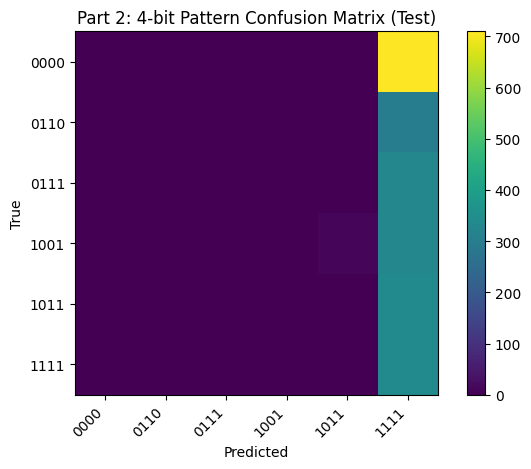

[[  0   0   0   0   0 710]
 [  0   0   0   0   0 301]
 [  0   0   0   0   0 329]
 [  0   0   0   0  10 329]
 [  0   0   0   0   0 340]
 [  0   0   0   0   0 340]]


In [28]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [29]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [30]:
class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()

        # 6 → 16
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        # 16 → 8
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        # 8 → 6 logits
        self.fc3 = nn.Linear(h2, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop2(x)

        logits = self.fc3(x)   # (N,6)

        return logits

In [31]:
# Create model
model_3 = DNN_MultiClass6().to(device)

# Loss function (CrossEntropy for multi-class)
loss_fn_3 = nn.CrossEntropyLoss()

# Optimizer (Adam + L2 regularization)
optimizer_3 = torch.optim.Adam(
    model_3.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

In [32]:
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # zero gradients
            optimizer_3.zero_grad()

            # logits
            logits = model(xb)

            # cross entropy loss
            loss = loss_fn_3(logits, yb)

            # backward + step
            loss.backward()
            optimizer_3.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()



In [33]:
train_part3(model_3, train_loader_3)

Epoch 1/1000 | Loss: 1.995106
Epoch 500/1000 | Loss: 0.636925
Epoch 1000/1000 | Loss: 0.619378



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.0000    0.0000    0.0000      1655
          LG     0.0000    0.0000    0.0000       790
          LL     0.1400    0.6558    0.2307       703
         LLG     0.4811    0.9924    0.6480       794
         LLL     0.0000    0.0000    0.0000       767
        LLLG     0.0000    0.0000    0.0000       793

    accuracy                         0.2270      5502
   macro avg     0.1035    0.2747    0.1465      5502
weighted avg     0.0873    0.2270    0.1230      5502



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


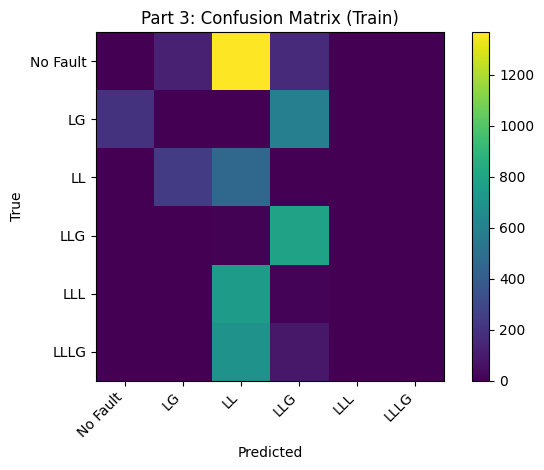


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.0000    0.0000    0.0000       710
          LG     0.0000    0.0000    0.0000       339
          LL     0.1369    0.6346    0.2252       301
         LLG     0.4878    1.0000    0.6557       340
         LLL     0.0000    0.0000    0.0000       329
        LLLG     0.0000    0.0000    0.0000       340

    accuracy                         0.2251      2359
   macro avg     0.1041    0.2724    0.1468      2359
weighted avg     0.0878    0.2251    0.1233      2359



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


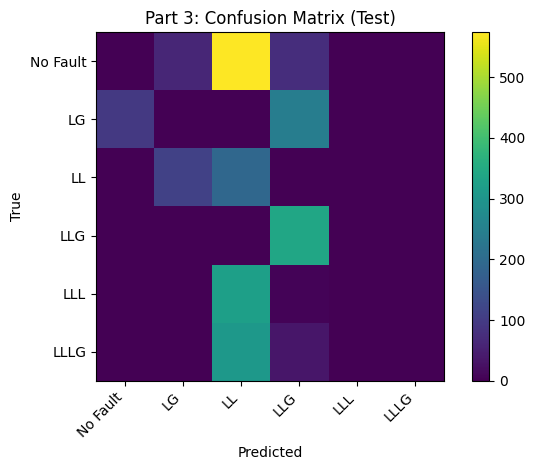

In [34]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1:
I think the multi-class formulation (Part 3) fits the dataset best. The dataset actually represents one specific fault type at a time, so treating it as a single 6-class classification problem makes more sense. In Parts 1 and 2, the model predicts each bit independently, which doesn’t fully capture the relationship between bits. Multi-class forces the model to choose one valid fault type, which matches the real setup better.
- Q2:
Yes, in the bit-based approaches (Part 1 and Part 2), there were some inconsistent 4-bit outputs that didn’t match any valid fault pattern. This happened because each bit was predicted independently, so the model could combine bits in unrealistic ways. That suggests the bit-level methods don’t enforce the logical structure of the fault types. It shows that treating the bits separately can lead to invalid combinations.
- Q3:
From the confusion matrices, classes like “No Fault,” “LG,” and some of the triple-line faults were the hardest to predict. The model often confused them with similar fault types, especially LL and LLG. One possible reason is that their feature patterns are very similar, so the model struggles to separate them clearly. This suggests the input features may not be strong enough to fully distinguish all six fault types.


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [35]:
y_binary = (y_fault != 0).astype(int)

In [36]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X,
    y_binary,
    test_size=0.3,
    stratify=y_binary,
    random_state=42
)

In [37]:
from sklearn.preprocessing import RobustScaler

scaler_b = RobustScaler()
X_train_b_s = scaler_b.fit_transform(X_train_b).astype(np.float32)
X_test_b_s  = scaler_b.transform(X_test_b).astype(np.float32)

# Torch tensors
Xtr_b = torch.from_numpy(X_train_b_s)
Xte_b = torch.from_numpy(X_test_b_s)
ytr_b = torch.from_numpy(y_train_b.astype(np.float32))
yte_b = torch.from_numpy(y_test_b.astype(np.float32))

train_loader_b = DataLoader(
    TensorDataset(Xtr_b, ytr_b),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [38]:
# Binary DNN

class DNN_Binary(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, p_drop=DROPOUT_P):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h2, 1)   # single logit
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [39]:
model_b = DNN_Binary().to(device)

loss_fn_b = nn.BCEWithLogitsLoss()

optimizer_b = torch.optim.Adam(
    model_b.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

In [40]:
def train_part5(model, loader, epochs=EPOCHS):
    model.train()

    for ep in range(1, epochs + 1):
        total = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_b.zero_grad()

            logits = model(xb)
            loss = loss_fn_b(logits, yb)

            loss.backward()
            optimizer_b.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}")

In [41]:
@torch.no_grad()
def predict_part5(model, X_np, threshold=0.5):
    model.eval()

    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()

    return (probs >= threshold).astype(int)

In [42]:
train_part5(model_b, train_loader_b)

Epoch 1/1000 | Loss: 0.678255
Epoch 500/1000 | Loss: 0.065180
Epoch 1000/1000 | Loss: 0.062286



=== Part 5 | Train ===
              precision    recall  f1-score   support

           0     0.9561    1.0000    0.9776      1655
           1     1.0000    0.9802    0.9900      3847

    accuracy                         0.9862      5502
   macro avg     0.9780    0.9901    0.9838      5502
weighted avg     0.9868    0.9862    0.9863      5502



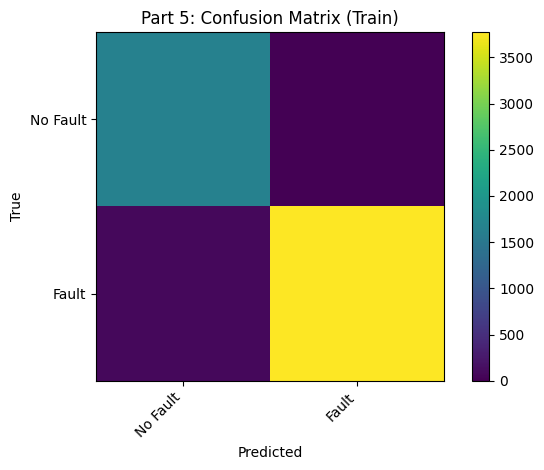


=== Part 5 | Test ===
              precision    recall  f1-score   support

           0     0.9660    1.0000    0.9827       710
           1     1.0000    0.9848    0.9924      1649

    accuracy                         0.9894      2359
   macro avg     0.9830    0.9924    0.9875      2359
weighted avg     0.9898    0.9894    0.9895      2359



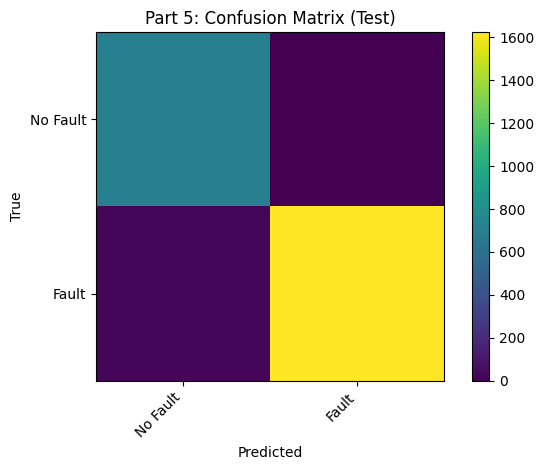

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

pred_train_b = predict_part5(model_b, X_train_b_s)
pred_test_b  = predict_part5(model_b, X_test_b_s)

print("\n=== Part 5 | Train ===")
print(classification_report(y_train_b, pred_train_b, digits=4))

cm_tr_b = confusion_matrix(y_train_b, pred_train_b)
plot_cm(cm_tr_b, "Part 5: Confusion Matrix (Train)", ["No Fault", "Fault"])

print("\n=== Part 5 | Test ===")
print(classification_report(y_test_b, pred_test_b, digits=4))

cm_te_b = confusion_matrix(y_test_b, pred_test_b)
plot_cm(cm_te_b, "Part 5: Confusion Matrix (Test)", ["No Fault", "Fault"])